# Collaborative Filtering for Polymarket

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares
from collections import defaultdict
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

c:\Users\euseb\anaconda3\envs\tools\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load data

In [2]:
from utils import load_trade_tags

df = load_trade_tags()

print(f"trades: {len(df):,}")
print(f"users: {df['user_id'].nunique():,}")
print(f"tags: {df['tag_id'].nunique():,}")
df.head()

Loading from 142 parquet files in 'df_trade_tags_cache/'...
trades: 14,259,585
users: 8,581
tags: 3,721


,user_id,tag_id,tag_label,timestamp,event_id,item,trade_count
0,0xd5039d967e6aafee9b778f2968120cf61fbd3a14,100215,All,2022-11-22 03:59:32,5828,will-donald-j-trump-win-the-us-2024-republican...,1
1,0xd5039d967e6aafee9b778f2968120cf61fbd3a14,126,Trump,2022-11-22 03:59:32,5828,will-donald-j-trump-win-the-us-2024-republican...,1
2,0xd5039d967e6aafee9b778f2968120cf61fbd3a14,143,u.s. 2024 republican presidential nomination,2022-11-22 03:59:32,5828,will-donald-j-trump-win-the-us-2024-republican...,1
3,0xd5039d967e6aafee9b778f2968120cf61fbd3a14,144,Elections,2022-11-22 03:59:32,5828,will-donald-j-trump-win-the-us-2024-republican...,1
4,0xd5039d967e6aafee9b778f2968120cf61fbd3a14,160,ron desantis,2022-11-22 03:59:32,5828,will-donald-j-trump-win-the-us-2024-republican...,1


## train/test split

In [25]:
# taking timestamp to split 80/20
trades = df[['user_id', 'event_id', 'item', 'timestamp']].drop_duplicates()
trades = trades.sort_values(['user_id', 'timestamp'])

trades['row_num'] = trades.groupby('user_id').cumcount()
trades['total'] = trades.groupby('user_id')['timestamp'].transform('size')
trades['cutoff'] = (trades['total'] * 0.8).astype(int).clip(lower=1, upper=trades['total']-1)
trades = trades[trades['total'] >= 2]

train_trades = trades[trades['row_num'] < trades['cutoff']]
test_trades = trades[trades['row_num'] >= trades['cutoff']]
# filtering users with at leat 2 trades
# This remove arund 5 users, because i encoutered some issues
train_df = df.merge(train_trades[['user_id', 'event_id', 'timestamp']], on=['user_id', 'event_id', 'timestamp'])
test_df = df.merge(test_trades[['user_id', 'event_id', 'timestamp']], on=['user_id', 'event_id', 'timestamp'])

print(f"train: {len(train_df):,}")
print(f"test: {len(test_df):,}")

train: 12,176,402
test: 2,694,197


In [26]:
# using trade counts
train_agg = train_df.groupby(['user_id', 'tag_id', 'tag_label'])['trade_count'].sum().reset_index()
test_agg = test_df.groupby(['user_id', 'tag_id', 'tag_label'])['trade_count'].sum().reset_index()

print(f"train pairs: {len(train_agg):,}")
print(f"test pairs: {len(test_agg):,}")

train pairs: 591,463
test pairs: 247,942


## build matrix

In [27]:
# indexes for the matrix 
users_cat = train_agg['user_id'].astype('category')
tags_cat = train_agg['tag_id'].astype('category')

user_to_id = {u: i for i, u in enumerate(users_cat.cat.categories)}
id_to_user = {i: u for u, i in user_to_id.items()}
tag_to_id = {t: i for i, t in enumerate(tags_cat.cat.categories)}
id_to_tag = {i: t for t, i in tag_to_id.items()}

n_users = len(user_to_id)
n_tags = len(tag_to_id)
print(f"matrix: {n_users} x {n_tags}")

matrix: 8380 x 3680


In [28]:
alpha = 40

row_id = users_cat.cat.codes.values
col_id = tags_cat.cat.codes.values
# confidence = 1 + alpha * log(1 + trades)
confidence = 1 + alpha * np.log1p(train_agg['trade_count'].values)

matrix = sparse.csr_matrix((confidence, (row_id, col_id)), shape=(n_users, n_tags))

density = matrix.nnz / (matrix.shape[0] * matrix.shape[1])
sparsity = 1 - density
print(f"sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

sparsity: 0.9808 (98.08%)


In [29]:
from utils import load_events_with_tags

events_df = load_events_with_tags()
events_df['event_id'].nunique()

Loading from 7 parquet files in 'events_tag_cache/'...


65056

In [30]:
event_tags = defaultdict(list)
event_titles = {}
tag_labels = {}

for _, row in events_df.iterrows():
    event_id = row['event_id']
    tag_id = row['tag_id']
    
    if tag_id in tag_to_id:
        t_id = tag_to_id[tag_id]
        event_tags[event_id].append(t_id)
        tag_labels[t_id] = row['tag_label']
    
    event_titles[event_id] = row['title']
len(event_tags)

65056

## train

In [31]:
import pickle

model = AlternatingLeastSquares(
    factors=64,     # factors 64 seems to have best results 
    regularization=0.05, #  prevent overfitting
    iterations=30,
    random_state=42
)

model.fit(matrix, show_progress=True)
model.save("../models/collaborative_filtering_model.npz")
with open("../models/cf_mappings.pkl", 'wb') as f:
        pickle.dump({
            'user_to_id': user_to_id,
            'tag_to_id': tag_to_id,
            'event_tags': dict(event_tags),  # Convert defaultdict to dict
            'event_titles': event_titles,
            'tag_labels': tag_labels
        }, f)

100%|██████████| 30/30 [00:02<00:00, 12.68it/s]


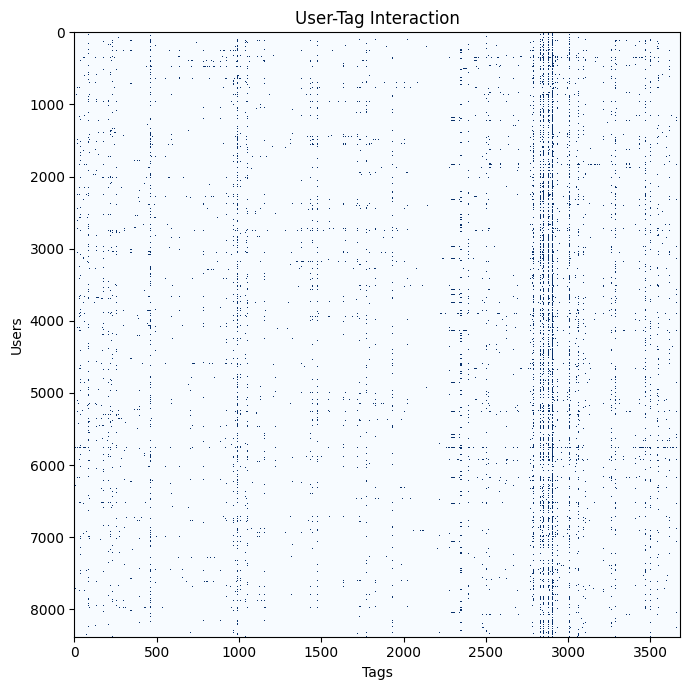

In [44]:
import matplotlib.pyplot as plt

cfmatrix = matrix.toarray()
n_users, n_tags = cfmatrix.shape
user_idx = np.random.choice(n_users, n_users, replace=False)
tag_idx = np.random.choice(n_tags, n_tags, replace=False)

sampled = cfmatrix[np.ix_(sorted(user_idx), sorted(tag_idx))]

fig, ax = plt.subplots(figsize=(7, 7))

# has interaction or not
binary_matrix = (sampled > 0).astype(int)

ax.imshow(binary_matrix, cmap='Blues', aspect='auto', interpolation='nearest')
ax.set_xlabel('Tags')
ax.set_ylabel('Users')
ax.set_title(f'User-Tag Interaction')

plt.tight_layout()
plt.show()

## evaluate

In [10]:
test_tags_by_user = test_agg.groupby('user_id')['tag_id'].apply(set).to_dict()

k = 10
precisions = []
hits = 0
total = 0

for user_id, true_tags in test_tags_by_user.items():
    if user_id not in user_to_id:
        continue
    
    u_id = user_to_id[user_id]
    rec_ids, scores = model.recommend(u_id, matrix[u_id], N=k, filter_already_liked_items=True)
    rec_tags = {id_to_tag[i] for i in rec_ids if i in id_to_tag}
    
    n_hits = len(rec_tags & true_tags)
    precisions.append(n_hits / k)
    
    if n_hits > 0:
        hits += 1
    total += 1

print(f"precision@{k}: {np.mean(precisions):.4f}")
print(f"hit rate@{k}: {hits/total:.4f}")
print(f"users: {total}")

precision@10: 0.0888
hit rate@10: 0.4677
users: 8380


In [11]:
test_events_by_user = test_df.groupby('user_id')['event_id'].apply(set).to_dict()
train_events_by_user = train_df.groupby('user_id')['event_id'].apply(set).to_dict()

k = 10
precisions = []
hits = 0
total = 0

for i, item in enumerate(test_events_by_user.items()):
    user_id, true_events = item

    if i % 11 == 0:
        pct = (i + 1) / len(test_events_by_user) * 100
        print(f"\rProcessing: {i + 1}/{len(test_events_by_user)} ({pct:5.1f}%)", end="", flush=True)
    
    #user id in the amtrix
    u_id = user_to_id[user_id]

    reccommendations_ids, scores = model.recommend(u_id, matrix[u_id], N=n_tags, filter_already_liked_items=False)
    # tag matrix id : score
    tag_scores = {reccommendations_ids[i]: scores[i] for i in range(len(reccommendations_ids))}
    
    #convert to event scores by averaging tags
    event_scores = {}
    for event_id, t_ids in event_tags.items():
        if t_ids:
            event_scores[event_id] = np.mean([tag_scores.get(t, 0) for t in t_ids])
    
    #filter out events user already traded
    train_events = train_events_by_user.get(user_id, set())
    valid_events = event_scores.keys() - train_events
    
    if len(valid_events) < k:
        continue

    sorted_events = sorted(((e, event_scores[e]) for e in valid_events), key=lambda x: -x[1])[:k]
    
    rec_events = {e for e, _ in sorted_events}
    
    n_hits = len(rec_events & true_events)
    precisions.append(n_hits / k)
    if n_hits > 0:
        hits += 1
    total += 1

print(f"precision@{k}: {np.mean(precisions):.4f}")
print(f"hit rate@{k}: {hits/total:.4f}")
print(f"users: {total}")

Processing: 8372/8380 ( 99.9%)precision@10: 0.0021
hit rate@10: 0.0184
users: 8380


## recommend events

In [12]:
def get_event_recs(user_id, n=5):
    if user_id not in user_to_id:
        return None
    
    u_id = user_to_id[user_id]
    
    # get tag scores from model
    rec_ids, scores = model.recommend(u_id, matrix[u_id], N=n_tags, filter_already_liked_items=False)
    tag_scores = {rec_ids[i]: scores[i] for i in range(len(rec_ids))}
    
    # score events by averaging tag scores
    event_scores = {}
    for event_id, t_ids in event_tags.items():
        if t_ids:
            event_scores[event_id] = np.mean([tag_scores.get(t, 0) for t in t_ids])
    
    # sort and take top n
    sorted_events = sorted(event_scores.items(), key=lambda x: -x[1])[:n]
    
    results = []
    for event_id, score in sorted_events:
        tags = [tag_labels[t] for t in event_tags[event_id]]
        results.append({
            'title': event_titles[event_id],
            'score': score,
            'tags': set(tags)
        })
    
    return results

In [13]:
# test
sample_user = "0x3428d8d085e8b9900768dcded987fba284694500"#list(user_to_id.keys())[10]
recs = get_event_recs(sample_user, n=5)

print(f"user: {sample_user}")
for i, r in enumerate(recs, 1):
    print(f"{i}. {r['title']}")
    print(f"\ttags: {r['tags']}")
    print(f"\tscore: {r['score']:.3f}\n")

user: 0x3428d8d085e8b9900768dcded987fba284694500
1. Will ETH hard fork before May?
	tags: {'Ethereum', 'Crypto'}
	score: 1.046

2. Ethereum ETF begins trading by July 26?
	tags: {'Ethereum', 'Crypto'}
	score: 1.046

3. What price will Ethereum hit in January?
	tags: {'Ethereum', 'Crypto Prices', 'Crypto'}
	score: 1.041

4. archEthereum all time high in May?
	tags: {'Ethereum', 'Crypto', 'Crypto Prices'}
	score: 1.041

5. Ethereum all time high in June?
	tags: {'Ethereum', 'Crypto Prices', 'Crypto'}
	score: 1.041

